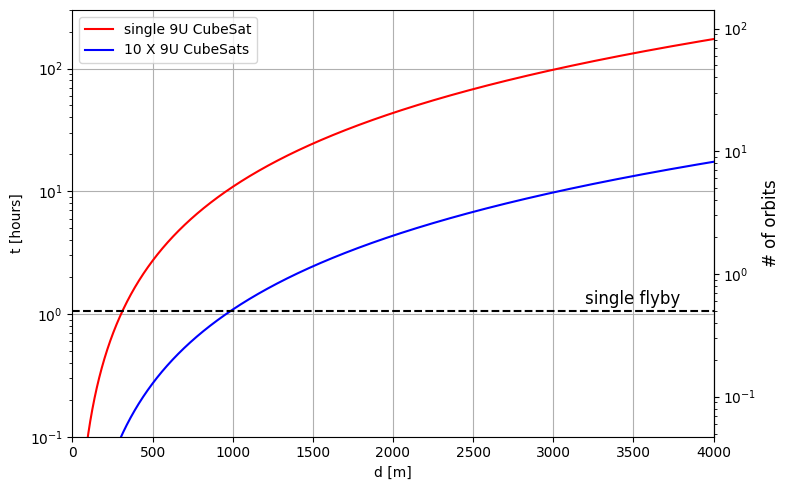

In [8]:
# Plot t vs d for n=1 and n=10 using the provided formula.
import numpy as np
import matplotlib.pyplot as plt

# Constants from the formula
factor_num = 6 * 5 * 4  # 120
factor_den = (0.3**2) * 0.77 * 0.0055 * 9.1e10

# Range for d (0..4000 meters)
d = np.linspace(0, 4000, 4001)  # 1-meter increments

def t_hours(d, n):
    return factor_num * np.pi * d**2 / factor_den / n  

# Compute t for n=1 and n=10
t_n1 = t_hours(d, 1)
t_n10 = t_hours(d, 10)

# Single chart with both curves
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(d, t_n1, label='single 9U CubeSat',color='red')
ax1.plot(d, t_n10, label='10 X 9U CubeSats',color='blue')
ax1.set_xlabel('d [m]')
ax1.set_ylabel('t [hours]')
ax1.set_yscale('log')
ax1.set_ylim(0.1, 300)   # <-- add this line to set left y-axis limits
ax1.set_xlim(0, 4000)
ax1.legend(loc='upper left')
ax1.grid(True)
#ax1.set_title('t vs d for n=1 and n=10')

# Secondary y-axis: primary axis divided by 2.12, labeled '# of orbits' (accurate mapping)
def to_orbits(x):
    return x / 2.12

def from_orbits(x):
    return x * 2.12

# create a secondary axis on the right that maps correctly to the left y-axis
ax2 = ax1.secondary_yaxis('right', functions=(to_orbits, from_orbits))
ax2.set_ylabel('# of orbits', fontsize=12)
ax2.tick_params(axis='y', labelsize=10)

# draw horizontal line at y=1.06 and label it
x_pos = ax1.get_xlim()[1] * 0.8
ax1.axhline(y=1.058, color='black', linestyle='--', linewidth=1.5)
ax1.text(x_pos, 1.058 * 1.05, 'single flyby', color='black', fontsize=12, va='bottom')

plt.tight_layout()
plt.savefig('time_vs_distance.pdf')
plt.show()